In [1]:
using Jens, Cosmology, Statistics, Plots
using Jens.LensAdaptiveGrid:RefinementMap, adaptive_grid_info, render_adaptive

# lens system

In [ ]:
cosmo = Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)

lens = Jens.LensModel.ComLens.MyLens(
    Jens.LensModel.SIE => (theta_E=1.2, e1=0.2, e2=0.08,
                           xcentre=0.0, ycentre=0.0))

src_profile  = Jens.LightModel.SersicLight.SersicSpheric
source_model = Jens.LightModel.ExtendedSource(
    src_profile; amp=1.0, Rsersic=0.15, n=2.0,
    xcentre=0.03, ycentre=0.02) 
grid = Jens.LensGenerator.GenGrid(pix_n=200)
pixel_scale = grid.pix_size

sys = Jens.LensSystem.ForwardModel(;
    lens_plane   = Jens.LensGenerator.LensedPlane(
        lens; z_lens=0.3, cosmology=cosmo),
    source_plane = source_model,
    grid         = grid,
    z_source     = 1.5,
    psf          = Jens.LensPSF.GaussianPSF(fwhm=0.08),  
)

Jens.LensSystem.ForwardModel{Jens.LensGenerator.LensedPlane{Module, Cosmology.FlatLCDM{Float64}}, Jens.LensGenerator.LightPlane{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}}, Jens.LensPSF.GaussianPSF{Float64}, Jens.LensGenerator.Grid, Nothing}(Jens.LensGenerator.LensedPlane{Module, Cosmology.FlatLCDM{Float64}}(Main.CombinedLens, 0.3, Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0)), Jens.LensGenerator.LightPlane{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}}(Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.0, Rsersic = 0.15, n = 2.0, xcentre = 0.03, ycentre

In [3]:
ref = RefinementMap(grid, lens; threshold=0.15, sub_n=4, z_source=1.5)
adaptive_grid_info(ref, grid)

AdaptiveGrid: 398/40401 pixels refined (1.0%)
  threshold: |detJ| < 0.15
  sub-sampling: 4×4
  total rays: 46371 (vs 40401 uniform)
  overhead: 14.8%


### Genral grid

In [5]:
@time model_uniform = Jens.LensSystem.render(sys);

  0.023465 seconds (110 allocations: 5.554 MiB, 81.69% gc time)


### adaptive grid

In [6]:
@time model_adaptive = render_adaptive(sys, ref);

  0.257511 seconds (2.05 M allocations: 97.854 MiB, 5.51% gc time, 87.10% compilation time)


### difference

In [12]:
diffimg = model_adaptive .- model_uniform;

### image

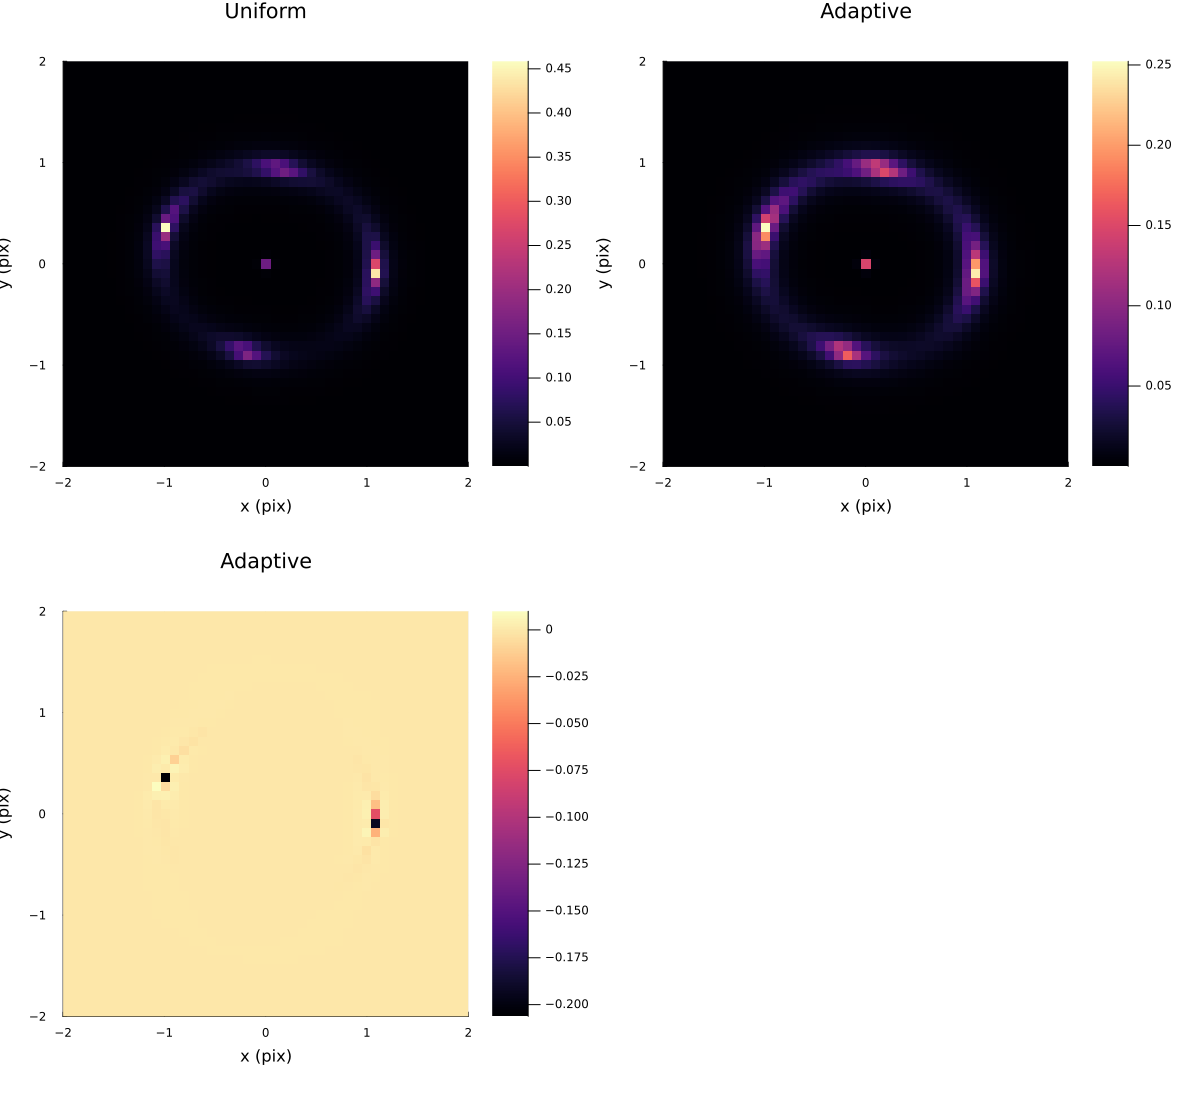

In [22]:
p1 = Jens.LensPlots.LensCanvas(; title="Uniform")
Jens.LensPlots.PlotPlane!(p1, grid.xg, grid.yg, model_uniform'; c=:magma)

p2 = Jens.LensPlots.LensCanvas(; title="Adaptive")
Jens.LensPlots.PlotPlane!(p2, grid.xg, grid.yg, model_adaptive'; c=:magma)

p3 = Jens.LensPlots.LensCanvas(; title="Adaptive")
Jens.LensPlots.PlotPlane!(p3, grid.xg, grid.yg, diffimg'; c=:magma)

fig = plot(p1, p2, p3; layout=(2, 2), size=(1200, 1100))